In [6]:
import numpy as np
import pandas as pd 
np.random.seed(123)

samples=1000
class0_ratio=0.9
nclass0=int(samples*class0_ratio)
nclass1=samples-nclass0 

In [7]:
## Create DF with imbalanced data set 
class0=pd.DataFrame({
    'f1': np.random.normal(loc=0,scale=1,size=nclass0),
    'f2': np.random.normal(loc=0,scale=1,size=nclass0),
    'target': [0]*nclass0 #Creates 900 zeros 0 
})
class1=pd.DataFrame({
    'f1': np.random.normal(loc=2,scale=1,size=nclass1),
    'f2': np.random.normal(loc=2,scale=1,size=nclass1),
    'target': [1]*nclass1 #Creates 100 ones 1
})

In [17]:
df=pd.concat([class0,class1]).reset_index(drop=True)
df

,f1,f2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0
...,...,...,...
995,1.376371,2.845701,1
996,2.239810,0.880077,1
997,1.131760,1.640703,1
998,2.902006,0.390305,1


In [21]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [49]:
## Up sampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

0      False
1      False
2      False
3      False
4      False
       ...  
995     True
996     True
997     True
998     True
999     True
Name: target, Length: 1000, dtype: bool

In [25]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True #Sample with replacement
         ,n_samples=len(df_majority),random_state=42)

In [33]:
df_minority_upsampled

,f1,f2,target
959,0.666001,1.894732,1
986,4.125817,1.784590,1
950,2.399896,-0.840847,1
932,1.915470,1.652041,1
944,0.542900,1.224480,1
...,...,...,...
948,1.023422,1.039398,1
904,3.033878,3.187417,1
969,2.917884,3.508705,1
991,3.701608,2.160889,1


In [36]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [37]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [39]:
#Down sampling same as creating the dataset and min and majority
from sklearn.utils import resample
df_majority_downsampled=resample(df_majority,replace=False #Sample with replacement
         ,n_samples=len(df_minority),random_state=42)

In [41]:
df_majority_downsampled.shape


(100, 3)

In [42]:
df_downsampled=pd.concat([df_majority_downsampled,df_minority])

In [44]:
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [2]:
#SMOTE Synthetic Minority Oversampling Technique

from sklearn.datasets import make_classification # helps create classification dataset

x,y=make_classification(n_samples=1000,n_features=2,n_redundant=0,n_clusters_per_class=1,weights=[0.9],random_state=12)

In [6]:
import pandas as pd 
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1) # Use axis=1 when add features column wise

In [7]:
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [8]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

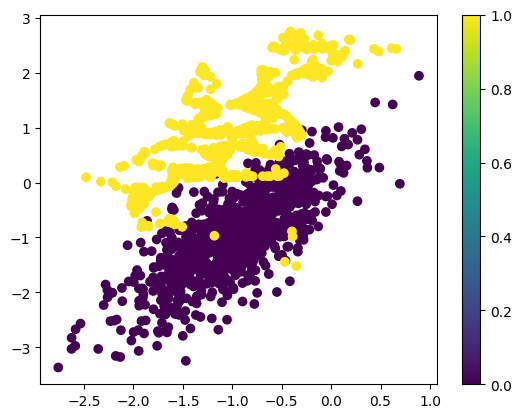

In [29]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])
plt.colorbar()

<Axes: xlabel='f1', ylabel='f2'>

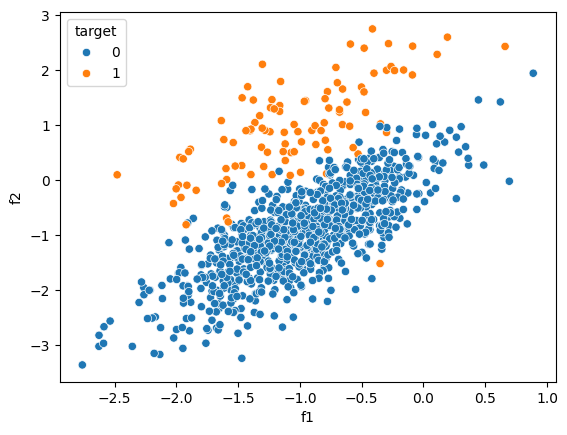

In [11]:
import seaborn as sns
sns.scatterplot(x='f1',y='f2',hue='target',data=final_df)

In [13]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from imblearn.over_sampling import SMOTE


In [15]:
## Transfering data using SMOTE 
oversample =SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target']) # FIRST INDEPENDENT FEATURES THEN TARGET

In [26]:
x

,f1,f2
0,-0.762898,-0.706808
1,-1.075436,-1.051162
2,-0.610115,-0.909802
3,-2.023284,-0.428945
4,-0.812921,-1.316206
...,...,...
1795,-0.715018,1.733087
1796,-0.829114,1.022171
1797,-1.237057,0.279241
1798,-1.291143,2.005167


In [17]:
y.shape

(1800,)

In [22]:
y[y==0]

0      0
1      0
2      0
4      0
5      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: target, Length: 900, dtype: int64

In [23]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1) # Use axis=1 when add features column wise

<Axes: xlabel='f1', ylabel='f2'>

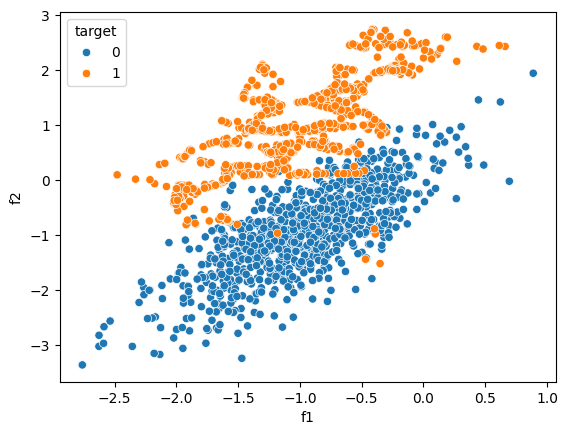

In [24]:
sns.scatterplot(x='f1',y='f2',hue='target',data=final_df)